In [33]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

In [34]:
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [35]:
df = pd.read_csv("EDA_dataset.csv")
df = df[df['year'] == 2025]

print(f"Total Reviews : {len(df):,}")

df.head()

Total Reviews : 60,170


,reviewId,content,score,time,bank,year
0,e17751da-bf2e-4a8f-a5a8-334206bb93ca,"ribet banget ni apk sumpah dikir' verif dikit' verif udhmah nyedot pulsa mulu, tolong benerin lah, jangan ribet gini mau pake aja ribet cuh",1,2025-12-31 23:57:59,BCAMOBILE_REVIEWS,2025
1,3481f1d1-a22f-445f-ae2f-ed8c2c9dca53,kenapa QRis ga bisa di pakai ya?? daritadi loading mulu. transfer uang juga gabisa,2,2025-12-31 23:22:32,BCAMOBILE_REVIEWS,2025
2,af69ec6d-cc97-404e-b86a-e5f5b5f1f711,"aplikasi nya sampah, kenapa tiba-tiba keluar terus registrasi ulang lagi, harus pake SMS pulsa pula, sangat tidak membantu ,delete",1,2025-12-31 23:06:58,BCAMOBILE_REVIEWS,2025
3,32d28ac6-c538-4749-969f-8af060915d96,bagus,3,2025-12-31 21:47:45,BCAMOBILE_REVIEWS,2025
4,f99259b7-0d45-4422-b667-6c4fd521638b,tidak ada solusi ketika ada kendala di persulit di lempar kesana kesini sangat mengecewakan harusnya respon dan solusi yang di berikan,1,2025-12-31 21:18:21,BCAMOBILE_REVIEWS,2025


dataset overview

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60170 entries, 0 to 186400
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  60170 non-null  object
 1   content   60170 non-null  object
 2   score     60170 non-null  int64 
 3   time      60170 non-null  object
 4   bank      60170 non-null  object
 5   year      60170 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 3.2+ MB


Rating Distribution

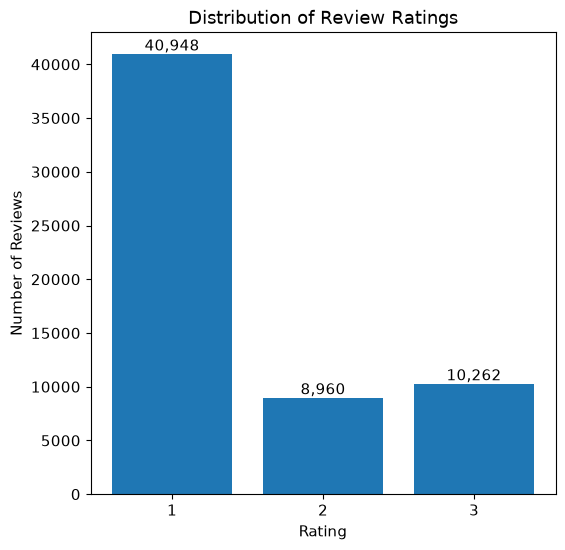

In [37]:
rating_count = (
    df["score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6,6))

plt.bar(
    rating_count.index.astype(str),
    rating_count.values
)

plt.title("Distribution of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, v in enumerate(rating_count.values):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.show()

most of the reviews dominated with 1 stars which is what we're hoping for for this research

Review Length (Characters)

In [38]:
df["character_length"] = (
    df["content"]
    .astype(str)
    .str.len()
)

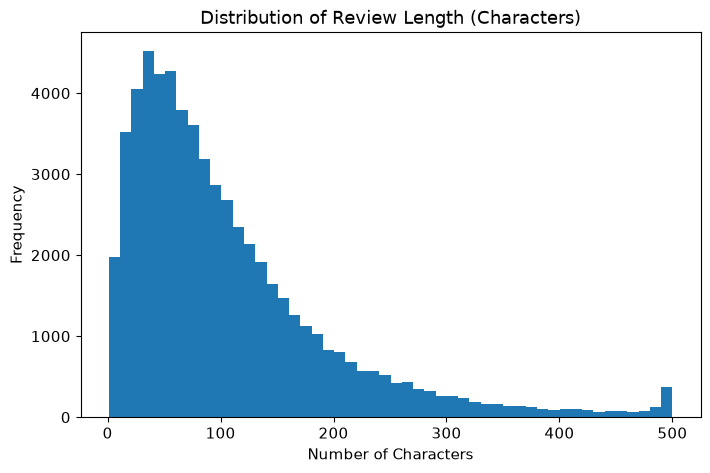

In [39]:
plt.figure(figsize=(8,5))

plt.hist(
    df["character_length"],
    bins=50
)

plt.title("Distribution of Review Length (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()


Review Length (Words)

In [40]:
df["word_length"] = (
    df["content"]
    .astype(str)
    .str.split()
    .str.len()
)

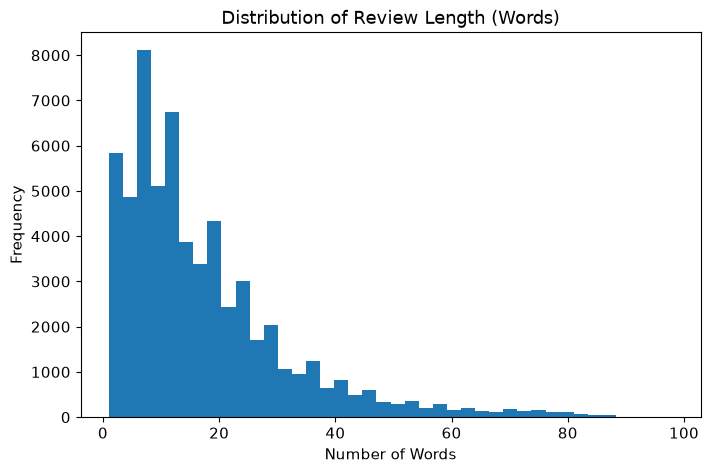

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    df["word_length"],
    bins=40
)

plt.title("Distribution of Review Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Review Timeline

In [42]:
df["time"] = pd.to_datetime(df["time"])

/tmp/ipykernel_3362/3879457033.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


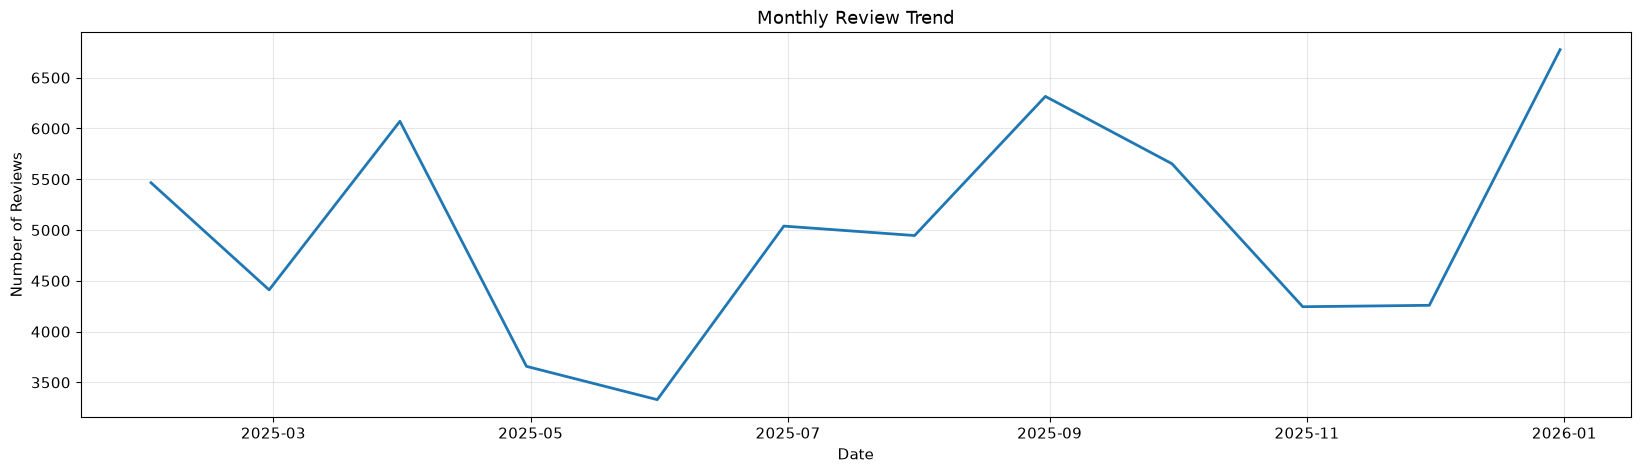

In [43]:
monthly_reviews = (
    df
    .set_index("time")
    .resample("M")
    .size()
)

plt.figure(figsize=(20,5))

plt.plot(
    monthly_reviews.index,
    monthly_reviews.values,
    linewidth=2
)

plt.title("Monthly Review Trend")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.grid(alpha=0.3)

plt.show()

short reviews 

In [45]:
df[
    df["word_length"] <= 3
][["content"]].head(20)

,content
3,bagus
25,sampah
37,mkain lemot
83,susah masuk login
89,aplikasi kacau
92,aplikasi buruk
111,merah terus !!!
112,jaringan merah mulu
152,potongan gak jelas!!
155,Aplikasi sering gangguan


longest reviews

In [46]:
df.nlargest(
    20,
    "word_length"
)[["word_length","content"]]

,word_length,content
46992,98,"saya mau isi saldo shoopay kok susah sekali ya, kalau mau isi saldo 2 juta aja ribet amat, hari ini trfer 1 juta pkek @wallet bisa, ntar kelang brpa jam gk bisa lagi. trz aku tfer 5rtus ribu bis, stlh itu gk bisa lagi, trz kirim lagi 3ratus bisa, trs sisanya mau trfer 2 ratus gk bisa lagi, jadi aku tf 100rbu bisa, mau tf lgi gk bisa lagi. adu pusing ya susah bner mau trfer ke shoopay aja ribet gitu. sebelumnya gk ada masalah mau tf brpa aja ke shoopay. sekarang ribet pusing gk tau salahnya dimna"
49056,98,"suruh buka rek di aplikasi brimo. awal pas di dkt satpam bisa di buka dan suruh isi dana 50rb abis itu blm sempat ketemu cs. kata satpam rek sdh bisa d gunakan. ok dong saya gak perlu ke cs karena klu tunggu cs katanya nanti jm3. hakirnya gue balik setelah berhasil gue tf 50rb ke rek yg baru gue buka. bsk nya gue mau buka aplikasi brimo tiba"" udh gk bisa di buka.sampe gue ke bank tdk di layanin dng baik. gue pake bca udh 20thn gak pernah ada kendala kaya bri dan dilayani dengan baik di bca"
123281,96,"awal nya laporan hp hilang, mu dftr livin baru. dengan nomor hp yg berbeda dr yg sblomnya .. eh malah nunggu 2 minggu . lama amaaatt beuh,BCA hr itu juga bisa ko . laporan hp hilang,lgsng bikin mbanking baru dgn krtu yg berbeda nah bca mah langsung bisa . ini ko dftar livin hrus nunggu 2 mnggu . ga gercep banget ,mana pas buka livin ko tiba2 ke blokir .baru jg smnggu dftar livin ,suruh nunggu 2 mnggu.1 mnggu aja ke blokir pas mu buka livin . ribet bnget sumpah ih mandiri. gabisa gercep kaya BCA"
115907,95,"sangat menyusahkan di era digital , krtu atm hilang , hrs k cabang , pengurusan atm 3 hr baru jd hrs bolak balik ke bank , di livin tidak bisa login , hrs k cabang lagi , sangat2 kesulitan , yg lain bikin atm bisa online , atm hilng/rusk bisa bikin online , atm di antr k alamat domisili , hanya video call 10 mnt beres , di lngkapi call senter bebas pls , sbnr nya dlm pengunaan sama aja , krna orng bnyk sibuk nya mngkin lbh baik bralih ke yg lbh mudah .."
125342,95,"Hingga saat ini apk Livin saya tidak bisa login lagi. Ntah apa masalah GK tau, bantuan cs nya juga GK ada di apk Livin. Jadi Livin itu seolah² GK ada gunanya. Bahkan juga GK berfungsi lagi. Apk nya hanya jadi pajangan saja di hp saya. Coba deh Livin itu jadi lebih baik lagi, masak saya tiba² GK bisa login. GK logika gitu. Data sudah saya masukin dengan benar. Tapi yg muncul data salah. Pusing gua. Udah dikluarin tiba² aja dari apk nya. Tolong di bantu lah. Uang masuk & kluar pun kita JD GK tau"
115278,94,"ni aplikasi dan bank gak bagus, selalu jam 12 malem eror, bank gak bisa 24 jam, ni gak patut nabung di sini bahaya, bgmna kalau org tua atau keluarga ada yg sakit dan minta tolong soal biaya di jam 12 malem, yg ada org bisa meninggal urusan nya, selalu eror dan gak layak buat di tabung ni bank mandiri, jangan lagi kawan2 tabung di bank mandiri, susah in org trus, setiap jam 12 jam 1 pasti eror, sekarang aja Uda eror 3 x, sya mau tutup rekening aja di mandiri, bank yg gak profesional,"
178473,94,aplikasi wondr payah hp ke reset sama anak pas mau masuk lagi suruh isi data KTP sama kartu ATM udah di isi semua pas terakhir foto Selfi kaga bisa bisa bolak balik masuk udah 3 hari kaga bisa juga cuma gara gara Selfi mata kedip kedip ga bisa juga sampe cape tiap hari pagi sore masih kaga bisa juga kan seharusnya asal data sesuai KTP sama kartu atm-nya sesuai udah ini malah di bikin ribet cuma Selfi ga berhasil terus kedipin mata coba sini depan cs gw kedipin mata pasti klepek klepek jatuh cint
46248,93,"jangan download apk ini abng2 ,fitur cs nya rusak ,udh tau chat cs nyari Soli biar gak Dateng k kantor eh si cs mlh nyuruh Dateng ke kantor mending klo masalah nya yg ribet mah ,masalah kecil juga langsung di suruh k kantor ,mending sekarang uang kalian yg ada di ATM cepet2 ambil deh keburu di blokir sama pihak bank sebulan 2 bulan GK ada transaksi blokir ditarik gak bisa giliran di isi gercep no lelet no slow respon ,fiks akhir jaman ,penip

checking weird comments

In [47]:
df["content"].str.fullmatch(r"[A-Za-z\s.,!?]+", na=False).value_counts()

content
True     40364
False    19806
Name: count, dtype: int64

In [48]:
df[
    df["content"].str.len() < 30
][["content"]].sample(30, random_state=42)

,content
40530,daftar aja gak bisa
179781,gak bisa verivikasi wajah
121116,kok gini sekarang
180628,bank payah sering bermasalah
122066,tdk bisa di Update
179053,aplikasinya bermasalah mulu
41944,Aplikasi sering eror
184149,Aplikasi nya lelet
58561,Lelet
111081,alikasi busuk


bank distribution

In [49]:
bank_count = (
    df["bank"]
    .value_counts()
    .sort_values(ascending=False)
)

bank_count

bank
BRIMO_REVIEWS            21209
LIVIN_MANDIRI_REVIEWS    16521
WONDR_BNI_REVIEWS        13644
BCAMOBILE_REVIEWS         8796
Name: count, dtype: int64

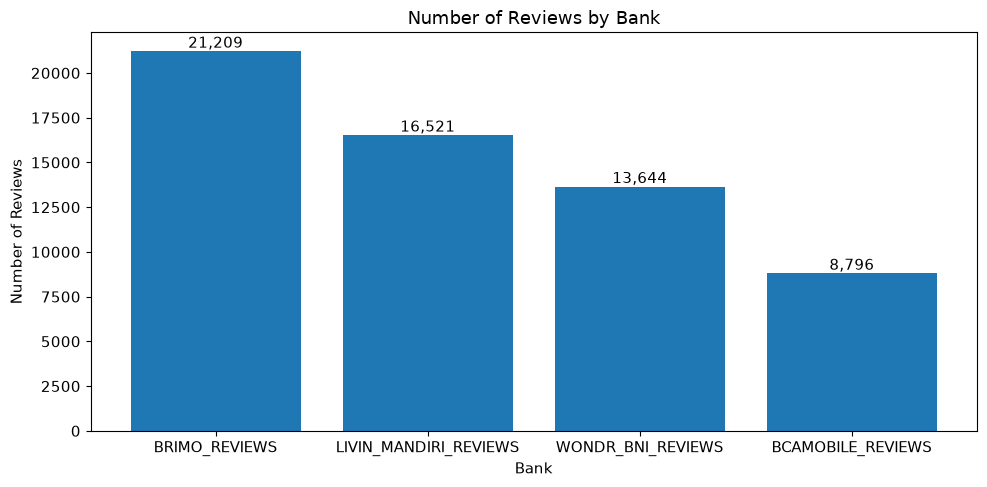

In [50]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    bank_count.index,
    bank_count.values
)

plt.title("Number of Reviews by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

pie chart per bank by percentage

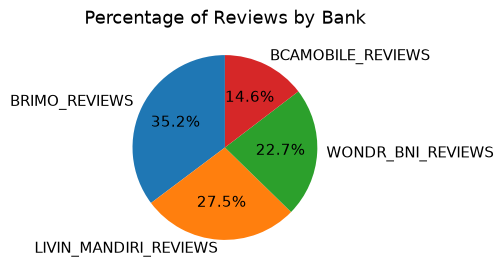

In [51]:
plt.figure(figsize=(3,3))

plt.pie(
    bank_count.values,
    labels=bank_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Reviews by Bank")

plt.show()